In [2]:
import eda
import pandas as pd
from pathlib import Path
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt

In [12]:
stimuli_dir = Path("stimuli")  
csv_path = stimuli_dir / f"civ_items_trial_8.csv"
df = pd.read_csv(csv_path)
numeric = df.drop(columns=["Name"], errors="ignore")
items = numeric.to_numpy(dtype=np.int64)

n_items = items.shape[0]
n_obj = items.shape[1] - 1
n_con = 1

if n_obj == 3:
    n_selected = 6
    max_row_diff = 5 
elif n_obj == 5:
    n_selected = 10
    max_row_diff = 500
else:
    raise ValueError(f"Number of objectives {n_obj} not supported")

capacity = n_selected * 10
pop_size = 1_000
generations = 100 
max_no_improve_gen = 5

# human input
aspi_item = np.array([77, 51, 126, 111, 86])
aspi_unit = aspi_item / np.linalg.norm(aspi_item)
item_scores = items[:, :n_obj] @ aspi_unit
r = item_scores.argsort().argsort().astype(float)
s = r / (r.max() + 1e-12)
logits = s / 0.3
logits -= logits.max() 
p_rank = np.exp(logits)
p_rank /= p_rank.sum()
# p_rank = None 

eda_process = eda.KnapsackEDA(
    items=items,
    capacity=capacity,
    n_selected=n_selected,
    n_obj=n_obj,
    pop_size=pop_size,
    generations=generations,
    max_no_improve_gen=max_no_improve_gen,
    max_row_diff=max_row_diff,
    seed=1123,
    p_rank=p_rank
)
results = eda_process.run()

if p_rank is not None:
    result_type = "eda_human"
else:
    result_type = "eda"

output_dir = "/home/tailai/multiobjective/eda_results"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, f"{result_type}_trial8_sub5.pkl")
if os.path.exists(file_path):
    print(f"File {file_path} already exists")
else:
    with open(file_path, 'wb') as f:
        pickle.dump(results, f)
    

Mode 1 generation 1 (no improve count: 0)
Mode 1 generation 2 (no improve count: 0)
Mode 1 generation 3 (no improve count: 0)
Mode 1 generation 4 (no improve count: 0)
Mode 1 generation 5 (no improve count: 1)
Mode 1 generation 6 (no improve count: 0)
Mode 1 generation 7 (no improve count: 0)
Mode 1 generation 8 (no improve count: 0)
Mode 1 generation 9 (no improve count: 0)
Mode 1 generation 10 (no improve count: 0)
Mode 1 generation 11 (no improve count: 1)
Mode 1 generation 12 (no improve count: 2)
Mode 1 generation 13 (no improve count: 3)
Mode 1 generation 14 (no improve count: 4)
Mode 1 generation 15 (no improve count: 0)
Mode 1 generation 16 (no improve count: 0)
Mode 1 generation 17 (no improve count: 1)
Mode 1 generation 18 (no improve count: 2)
Mode 1 generation 19 (no improve count: 3)
Mode 1 generation 20 (no improve count: 4)
Mode 2 generation 1 (no improve count: 0)
Mode 2 generation 2 (no improve count: 0)
Mode 2 generation 3 (no improve count: 0)
Mode 2 generation 4 (no

In [3]:
with open('eda_results/eda_human_trial8_sub5.pkl', 'rb') as f:
    results = pickle.load(f)
# with open('eda_results/eda_trial0_selected5.pkl', 'rb') as f:
#     results4 = pickle.load(f)
# with open('eda_results/eda_trial0_selected4.pkl', 'rb') as f:
#     results5 = pickle.load(f)

In [4]:
pf_df = pd.read_csv("eda_results/pf_trial8.csv", header=None)
pf = pf_df.to_numpy()

In [5]:
pf_human = results['converged_pf_table'][-1]

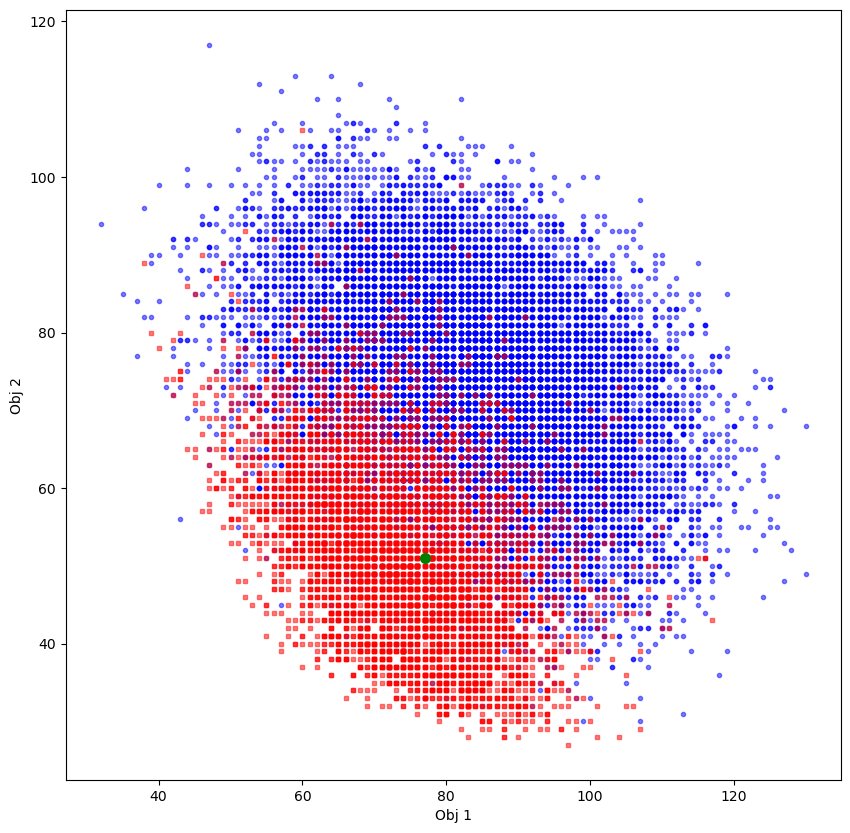

In [6]:
from matplotlib import pyplot as plt
# %matplotlib widget
# from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot()
# ax = fig.add_subplot(projection='3d')
ax.plot(pf[:,0], pf[:,1], 'bo', alpha=0.5, markersize=3)
ax.plot(pf_human[:,0], pf_human[:,1], 'rs', alpha=0.5, markersize=3)
ax.plot(77, 51, 'go', alpha=1, markersize=7)
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
plt.show()

In [20]:
def calculate_dominance(pf_predicted, pf_actual, n_obj):
    dominance = np.zeros(len(pf_actual))
    for j in range(len(pf_actual)):
        if np.all(pf_actual[j, :n_obj] >= pf_predicted[:n_obj]) and \
            np.any(pf_actual[j, :n_obj] > pf_predicted[:n_obj]):
            dominance[j] = 1
    return dominance, np.sum(dominance), np.sum(dominance)/len(pf_actual)
dominance, num_dominance, ratio_dominance = calculate_dominance([77, 51, 126, 111, 86], pf_human, 5)
print(num_dominance)
print(ratio_dominance)

3.0
0.0005275189027606822


In [21]:
# check number of objectives won
def calculate_win(pf_predicted, pf_actual, n_obj):
    win = np.zeros(len(pf_actual))
    for j in range(len(pf_actual)):
        win[j] = np.sum(pf_actual[j, :n_obj] > pf_predicted[:n_obj])
    return win, np.mean(win)
num_win, mean_win = calculate_win([77, 51, 126, 111, 86], pf_human, 5)
print(num_win)
print(mean_win)

[3. 2. 3. ... 1. 1. 1.]
2.710567962018639


In [7]:
def calculate_dominated(pf_predicted, pf_actual, n_obj):
    dominated = np.zeros(len(pf_predicted))
    for i in range(len(pf_predicted)):
        for j in range(len(pf_actual)):
            if np.all(pf_actual[j, :n_obj] >= pf_predicted[i, :n_obj]) and \
                np.any(pf_actual[j, :n_obj] > pf_predicted[i, :n_obj]):
                dominated[i] = 1
                break
    return dominated, np.sum(dominated), np.sum(dominated)/len(pf_predicted)
dominated, num_dominated, ratio_dominated = calculate_dominated(pf_human, pf, 5)
print(ratio_dominated)

0.017232284156848954


In [15]:
# Find row in pf closest (Euclidean) to target vector [88, 56, 56]
target = np.array([83, 53, 50])
pf_obj = pf[:, :3] if pf.shape[1] >= 3 else pf  # use first 3 objective columns
distances = np.linalg.norm(pf_obj - target, axis=1)
idx = np.argmin(distances)
closest_row = pf[idx]
print(f"Closest row index: {idx}")
print(f"Closest row: {closest_row}")
print(f"Euclidean distance: {distances[idx]:.2f}")

Closest row index: 279
Closest row: [88 56 56]
Euclidean distance: 8.37


In [ ]:
## generate example
# eg1 = df.iloc[pareto_indices[-1]]
# eg1 = eg1.copy()
# eg1 = eg1.drop(index='Total', errors='ignore')
# eg1.loc['Total'] = ['Sum',
#                     eg1['Economy'].sum(),
#                     eg1['Military'].sum(),
#                     eg1['Culture'].sum(),
#                     eg1['Cost'].sum()]

,Name,Economy,Military,Culture,Cost
0,Stock,11,2,11,4
4,Oil Refining,14,5,4,3
5,Warehouse,14,1,8,7
6,Highways,15,7,15,17
7,Free Trade,15,2,4,3
8,Tax Cuts,17,3,6,13


In [51]:
results_dir = Path("eda_results")
for i in range(11):
    results_path = results_dir / f"eda_trial{i}.pkl"
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    pf = results['converged_pf_table'][-1]
    pf_df = pd.DataFrame(pf)
    pf_df.to_csv(f'eda_results/pf_trial{i}.csv', index=False, header=False)